[3/24]
1.고객 행동 흐름 확인 => **offer received → offer viewed → offer completed** 순서로 구성되며 추적이 가능한 구조임을 확인
2.오퍼 전환율 확인(completed / received) => reward, difficulty, channel별로 확인

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df_merged = pd.read_csv("clean_data/starbucks_merge.csv", index_col=0)


# ============================================================
# 2. 데이터 기본 구조 확인
# ============================================================
print("===== 기본 크기 확인 =====")
print("\n[merged]")
print("shape :", df_merged.shape)
display(df_merged.head())
print()

===== 기본 크기 확인 =====

[merged]
shape : (306137, 19)


,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing
customer_id,,,,,,,,,,,,,,,,,,,
78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


In [4]:
print(df_merged.columns)
print(df_merged.head())

Index(['event', 'time', 'offer_id', 'amount', 'event_reward', 'offer_type',
       'offer_reward', 'difficulty', 'duration', 'channels', 'web', 'email',
       'mobile', 'social', 'gender', 'age', 'income', 'became_member_on',
       'profile_missing'],
      dtype='str')
                                           event  time  \
customer_id                                              
78afa995795e4d85b5d9ceeca43f5fef  offer received     0   
a03223e636434f42ac4c3df47e8bac43  offer received     0   
e2127556f4f64592b11af22de27a7932  offer received     0   
8ec6ce2a7e7949b1bf142def7d0e0586  offer received     0   
68617ca6246f4fbc85e91a2a49552598  offer received     0   

                                                          offer_id  amount  \
customer_id                                                                  
78afa995795e4d85b5d9ceeca43f5fef  9b98b8c7a33c4b65b9aebfe6a799e6d9     NaN   
a03223e636434f42ac4c3df47e8bac43  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN   
e2127556

In [5]:
df_merged = df_merged.reset_index()
print(df_merged.columns)

Index(['customer_id', 'event', 'time', 'offer_id', 'amount', 'event_reward',
       'offer_type', 'offer_reward', 'difficulty', 'duration', 'channels',
       'web', 'email', 'mobile', 'social', 'gender', 'age', 'income',
       'became_member_on', 'profile_missing'],
      dtype='str')


In [7]:
# offer received
df_received = df_merged[df_merged["event"] == "offer received"]

# offer completed
df_completed = df_merged[df_merged["event"] == "offer completed"]

# offer_id 기준 집계
received = df_received.groupby("offer_id")["customer_id"].nunique()
completed = df_completed.groupby("offer_id")["customer_id"].nunique()

conversion_df = pd.concat([received, completed], axis=1)
conversion_df.columns = ["received", "completed"]

conversion_df["conversion_rate"] = (
    conversion_df["completed"] / conversion_df["received"]
)

print(conversion_df)

                                  received  completed  conversion_rate
offer_id                                                              
0b1e1539f2cc45b7b9fa7c272da2e1d7      6374     2978.0         0.467211
2298d6c36e964ae4a3e7e9706d1fb8c2      6325     4421.0         0.698972
2906b810c7d4411798c6938adc9daaa5      6285     3480.0         0.553699
3f207df678b143eea3cee63160fa8bed      6331        NaN              NaN
4d5c57ea9a6940dd891ad53e9dbe8da0      6330     2885.0         0.455766
5a8bc65990b245e5a138643cd4eb9837      6320        NaN              NaN
9b98b8c7a33c4b65b9aebfe6a799e6d9      6355     3784.0         0.595437
ae264e3637204a6fb9bb56bc8210ddfd      6374     3177.0         0.498431
f19421c1d4aa40978ebb69ca19b0e20d      6262     3741.0         0.597413
fafdcd668e3743c1bb461111dcafc2a4      6332     4530.0         0.715414


In [8]:
# 전환 고객 리스트
converted_customers = df_completed["customer_id"].unique()

# 라벨링
df_merged["converted"] = df_merged["customer_id"].isin(converted_customers).astype(int)

In [9]:
# viewed
df_viewed = df_merged[df_merged["event"] == "offer viewed"]

viewed = df_viewed.groupby("offer_id")["customer_id"].nunique()

conversion_df["viewed"] = viewed

# viewed → completed 전환율
conversion_df["view_to_complete_rate"] = (
    conversion_df["completed"] / conversion_df["viewed"]
)

In [10]:
# 1. 이벤트별 데이터 분리
df_received = df_merged[df_merged["event"] == "offer received"]
df_viewed = df_merged[df_merged["event"] == "offer viewed"]
df_completed = df_merged[df_merged["event"] == "offer completed"]

# 2. offer 기준 집계
received = df_received.groupby("offer_id")["customer_id"].nunique()
viewed = df_viewed.groupby("offer_id")["customer_id"].nunique()
completed = df_completed.groupby("offer_id")["customer_id"].nunique()

# 3. 하나로 합치기
funnel_df = pd.concat([received, viewed, completed], axis=1)
funnel_df.columns = ["received", "viewed", "completed"]

# 4. 전환율 계산
funnel_df["view_rate"] = funnel_df["viewed"] / funnel_df["received"]
funnel_df["completion_rate"] = funnel_df["completed"] / funnel_df["viewed"]
funnel_df["total_conversion_rate"] = funnel_df["completed"] / funnel_df["received"]

# 보기 좋게 정리
funnel_df = funnel_df.fillna(0)

print(funnel_df)

                                  received  viewed  completed  view_rate  \
offer_id                                                                   
0b1e1539f2cc45b7b9fa7c272da2e1d7      6374    2400     2978.0   0.376530   
2298d6c36e964ae4a3e7e9706d1fb8c2      6325    6122     4421.0   0.967905   
2906b810c7d4411798c6938adc9daaa5      6285    3608     3480.0   0.574065   
3f207df678b143eea3cee63160fa8bed      6331    3635        0.0   0.574159   
4d5c57ea9a6940dd891ad53e9dbe8da0      6330    6132     2885.0   0.968720   
5a8bc65990b245e5a138643cd4eb9837      6320    5674        0.0   0.897785   
9b98b8c7a33c4b65b9aebfe6a799e6d9      6355    3658     3784.0   0.575610   
ae264e3637204a6fb9bb56bc8210ddfd      6374    5696     3177.0   0.893630   
f19421c1d4aa40978ebb69ca19b0e20d      6262    6060     3741.0   0.967742   
fafdcd668e3743c1bb461111dcafc2a4      6332    6150     4530.0   0.971257   

                                  completion_rate  total_conversion_rate  
offer_id    

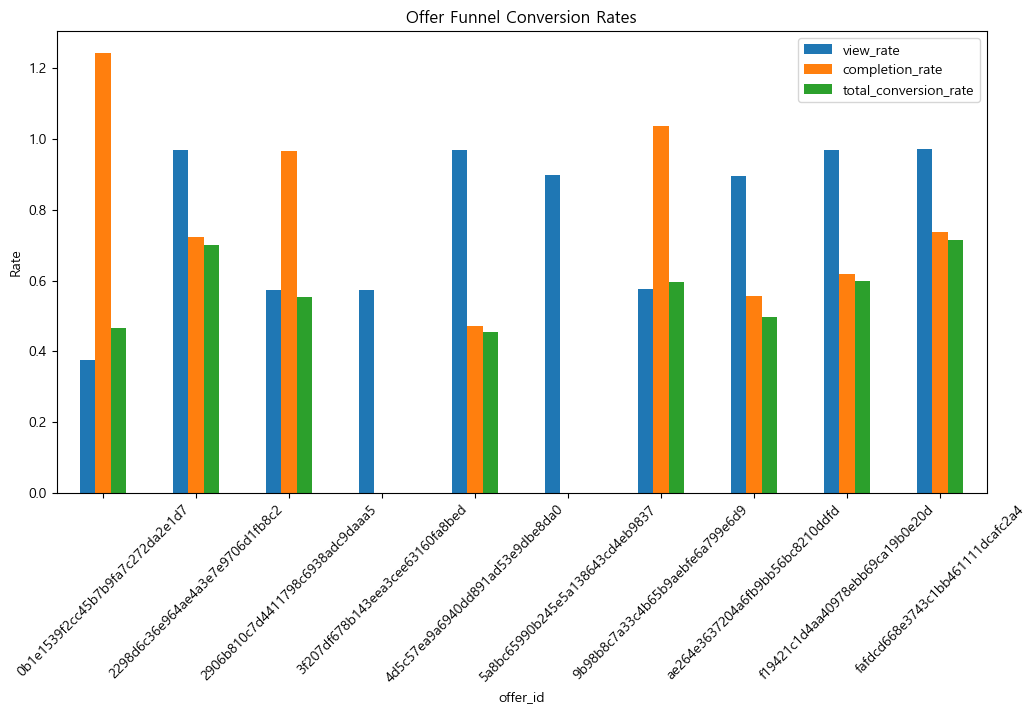

In [11]:
import matplotlib.pyplot as plt

funnel_df[["view_rate", "completion_rate", "total_conversion_rate"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Offer Funnel Conversion Rates")
plt.ylabel("Rate")
plt.xticks(rotation=45)
plt.show()

In [12]:
funnel_type = df_merged.groupby(["offer_type", "event"])["customer_id"].nunique().unstack().fillna(0)

funnel_type["view_rate"] = funnel_type["offer viewed"] / funnel_type["offer received"]
funnel_type["completion_rate"] = funnel_type["offer completed"] / funnel_type["offer viewed"]
funnel_type["total_conversion_rate"] = funnel_type["offer completed"] / funnel_type["offer received"]

print(funnel_type)

event          offer completed  offer received  offer viewed  view_rate  \
offer_type                                                                
bogo                    9263.0         14992.0       14008.0   0.934365   
discount               10289.0         14945.0       12676.0   0.848177   
informational              0.0         10547.0        8251.0   0.782308   

event          completion_rate  total_conversion_rate  
offer_type                                             
bogo                  0.661265               0.617863  
discount              0.811691               0.688458  
informational         0.000000               0.000000  


<Axes: xlabel='offer_type'>

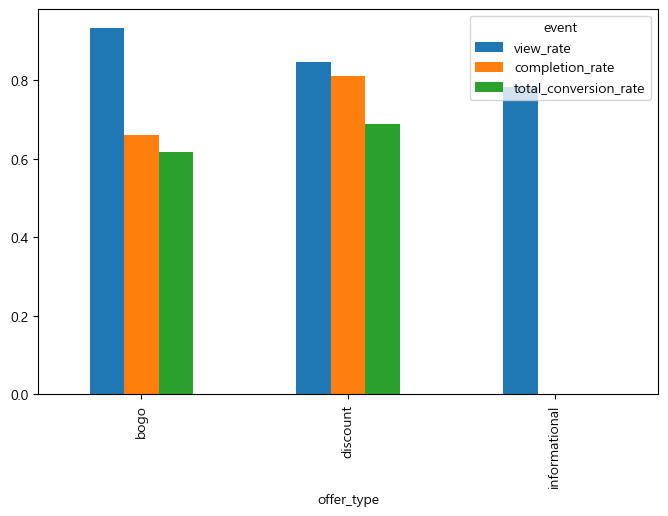

In [13]:
funnel_type[["view_rate", "completion_rate", "total_conversion_rate"]].plot(
    kind="bar",
    figsize=(8,5)
)

[view_rate (보냄 → 확인)]
bogo: 0.93 (매우 높음)
discount: 0.85
informational: 0.78

=> “무료/보상형(bogo)이 클릭을 잘 유도함”


[completion_rate (확인 → 구매)]
bogo: 0.66
discount: 0.81 (압도적 1위)

=> discount는 본 순간 거의 산다 => 할인은 구매를 직접 유도하는 힘이 강함
bogo는 관심 대비 구매는 약간 떨어짐


[total_conversion_rate (최종)]
bogo: 0.61
discount: 0.68 (최고)

결론: discount 오퍼가 최고다

#12 **프로모션 고객 행동 흐름 추적 가능성 검토**

In [6]:
print(df_merged["event"].value_counts())

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33182
Name: count, dtype: int64


In [7]:
# offer 이벤트만 필터링
df_offer = df_merged[
    df_merged["event"].isin(["offer received", "offer viewed", "offer completed"])
].copy()

# 정렬 
df_offer = df_offer.sort_values(["customer_id", "offer_id", "time"])

In [8]:
# 고객 + 오퍼 단위로 이벤트 리스트 생성
funnel_check = (
    df_offer.groupby(["customer_id", "offer_id"])["event"]
    .apply(list)
    .reset_index()
)

display(funnel_check.head())

,customer_id,offer_id,event
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,"[offer received, offer completed]"
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,"[offer received, offer viewed]"
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,"[offer received, offer viewed]"
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,"[offer received, offer completed, offer viewed]"
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,"[offer received, offer completed, offer viewed]"


In [9]:
def classify_funnel(events):
    if "offer completed" in events:
        return "completed"
    elif "offer viewed" in events:
        return "viewed_only"
    elif "offer received" in events:
        return "received_only"
    else:
        return "other"

funnel_check["funnel_stage"] = funnel_check["event"].apply(classify_funnel)

print(funnel_check["funnel_stage"].value_counts(normalize=True))

funnel_stage
completed        0.458160
viewed_only      0.389884
received_only    0.151956
Name: proportion, dtype: float64


In [10]:
def check_order(events):
    order = ["offer received", "offer viewed", "offer completed"]
    return events == sorted(events, key=lambda x: order.index(x) if x in order else 99)

funnel_check["valid_order"] = funnel_check["event"].apply(check_order)

print(funnel_check["valid_order"].value_counts())

valid_order
True     50720
False    12568
Name: count, dtype: int64


In [11]:
# transaction만 따로
df_tx = df_merged[df_merged["event"] == "transaction"]

# offer 있는 경우만
df_tx_offer = df_tx[df_tx["offer_id"].notnull()]

print("transaction 중 offer_id 존재 비율:")
print(len(df_tx_offer) / len(df_tx))

transaction 중 offer_id 존재 비율:
0.0


[결론]
- received_only (15%) : 채널 or 추시 개선 필요
- viewed_only (38.9%) : 중요 대상 -> 전체의 거의 40%가 여기서 이탈
오퍼 매력 부족
reward 낮음
difficulty 높음

- completed (45.8%)

- transaction 기반 전환율 분석 -> 불가능
- offer 기반 퍼널 분석 -> 정답

[확실한 검증]
1. **received 없이 viewed 있는가? - 받은적이 없는데 볼 수가 있나?**
2. received 없이 completed 있는가? - 받은적이 없는데 완료할...수는 있을지도
3. viewed 없이 completed 있는가? - 본적은 없어도 완료할 수는 있을지도
4. 순서가 뒤집힌 경우 있는가?

In [12]:
# 고객 + 오퍼 기준 이벤트 집합
event_set = (
    df_merged.groupby(["customer_id", "offer_id"])["event"]
    .apply(set)
    .reset_index()
)

event_set.head()

,customer_id,offer_id,event
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,"{offer received, offer completed}"
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,"{offer received, offer viewed}"
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,"{offer received, offer viewed}"
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,"{offer received, offer viewed, offer completed}"
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,"{offer received, offer viewed, offer completed}"


In [13]:
def check_anomaly(events):
    has_received = "offer received" in events
    has_viewed = "offer viewed" in events
    has_completed = "offer completed" in events
    
    if (not has_received) and has_viewed:
        return "view_without_received"
    elif (not has_received) and has_completed:
        return "complete_without_received"
    elif has_completed and (not has_viewed):
        return "complete_without_view"
    else:
        return "normal"

event_set["case"] = event_set["event"].apply(check_anomaly)

event_set["case"].value_counts()

case
normal                   58752
complete_without_view     4536
Name: count, dtype: int64

In [14]:
event_set["case"].value_counts(normalize=True)

case
normal                   0.928328
complete_without_view    0.071672
Name: proportion, dtype: float64

In [15]:
# 이벤트 순서 리스트
event_seq = (
    df_merged.sort_values(["customer_id", "offer_id", "time"])
    .groupby(["customer_id", "offer_id"])["event"]
    .apply(list)
    .reset_index()
)

event_seq.head()

,customer_id,offer_id,event
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,"[offer received, offer completed]"
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,"[offer received, offer viewed]"
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,"[offer received, offer viewed]"
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,"[offer received, offer completed, offer viewed]"
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,"[offer received, offer completed, offer viewed]"


In [16]:
def check_order(events):
    order_map = {
        "offer received": 1,
        "offer viewed": 2,
        "offer completed": 3
    }
    mapped = [order_map.get(e, 99) for e in events]
    return mapped == sorted(mapped)

event_seq["valid_order"] = event_seq["event"].apply(check_order)

event_seq["valid_order"].value_counts(normalize=True)

valid_order
True     0.801416
False    0.198584
Name: proportion, dtype: float64

[결론]
1. 오퍼를 받지 않았는데 본 경우 or 받지 않았는데 완료한 경우는 없었다
=> offer received → viewed → completed 고객 행동 흐름이 데이터상 성립한다는 분명한 근거

2. 예외인 complete_without_view 7.17%의 경우 오류로 보기는 어렵다
=> view 이벤트 누락 또는 비명시적 확인 후 완료로 볼 수 있으므로 이 케이스는 “논리적 오류”라기 보단 데이터의 이벤트 기록 한계

3. valid_order = True가 80.14%의 경우 완벽하진 않지만, 대부분의 고객-오퍼 조합에서 시간 순서가 정상적이라는 의미이다.
=> 19.86%의 순서 불일치는 로그 지연, 동일 시간 기록, 이벤트 적재 순서 문제 같은 데이터 품질 이슈 가능성이 높음.
=> 퍼널 분석 자체를 버릴 정도는 아니며 개별 고객 단위의 정밀 추적보다는 "집계 수준 퍼널 분석"에 더 적합하다

[전환율 어떻게 할것인가?]
: 생각해보니 전환율은 1개가 아니다. 일단 메인 KPI를 오퍼 단위로 잡고 그 후 고객 세그먼트를 볼때 고객 전환율로 가야맞다.
- 오퍼 단위 전환율 = completed / received
- 고객 전환율 = (기간 내 1번 이상 completed 고객 비율)

In [ ]:
# reward 영향
df_received = df_merged[df_merged["event"] == "offer received"]
df_completed = df_merged[df_merged["event"] == "offer completed"]

received = df_received.groupby("offer_reward")["customer_id"].nunique()
completed = df_completed.groupby("offer_reward")["customer_id"].nunique()

reward_df = pd.concat([received, completed], axis=1)
reward_df.columns = ["received", "completed"]

reward_df["conversion_rate"] = reward_df["completed"] / reward_df["received"]

print(reward_df.sort_values("conversion_rate", ascending=False))

              received  completed  conversion_rate
offer_reward                                      
3.0               6325     4421.0         0.698972
2.0              10482     6940.0         0.662087
5.0              13326     8116.0         0.609035
10.0             10586     5234.0         0.494427
0.0              10547        NaN              NaN


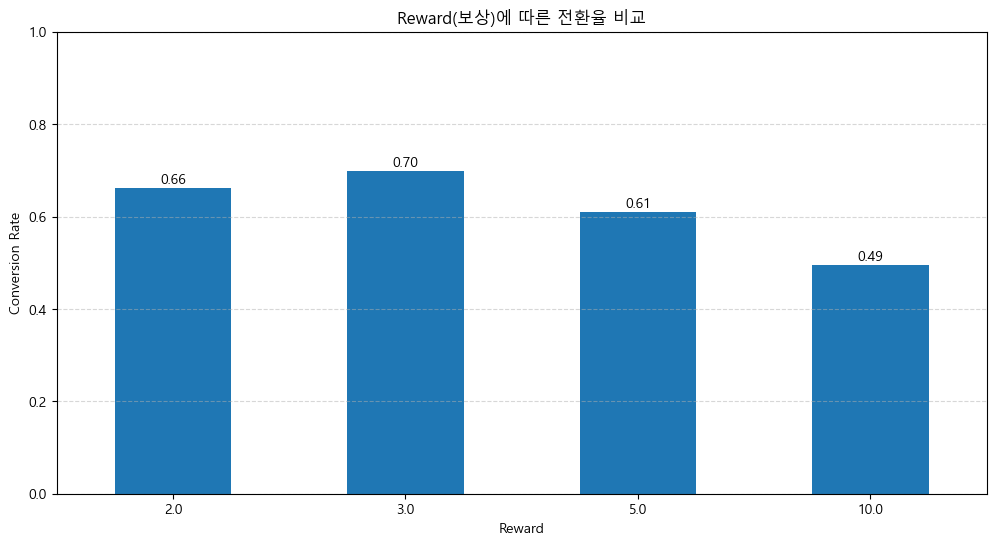

In [40]:
reward_plot = reward_df.dropna(subset=["conversion_rate"])

reward_plot["conversion_rate"].plot(kind="bar")

plt.title("Reward(보상)에 따른 전환율 비교")
plt.xlabel("Reward")
plt.ylabel("Conversion Rate")

plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 값 표시
for i, v in enumerate(reward_plot["conversion_rate"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()


- rewardr가 크다고 전환율이 올라가진 않는다
- reward 10이 낮은 이유: 조건(difficulty) 높을 가능성, 고객 부담 증가

In [18]:
# difficulty 영향
received = df_received.groupby("difficulty")["customer_id"].nunique()
completed = df_completed.groupby("difficulty")["customer_id"].nunique()

diff_df = pd.concat([received, completed], axis=1)
diff_df.columns = ["received", "completed"]

diff_df["conversion_rate"] = diff_df["completed"] / diff_df["received"]

print(diff_df.sort_values("conversion_rate", ascending=False))

            received  completed  conversion_rate
difficulty                                      
7.0             6325     4421.0         0.698972
10.0           14925     9521.0         0.637923
5.0            10539     6575.0         0.623873
20.0            6374     2978.0         0.467211
0.0            10547        NaN              NaN


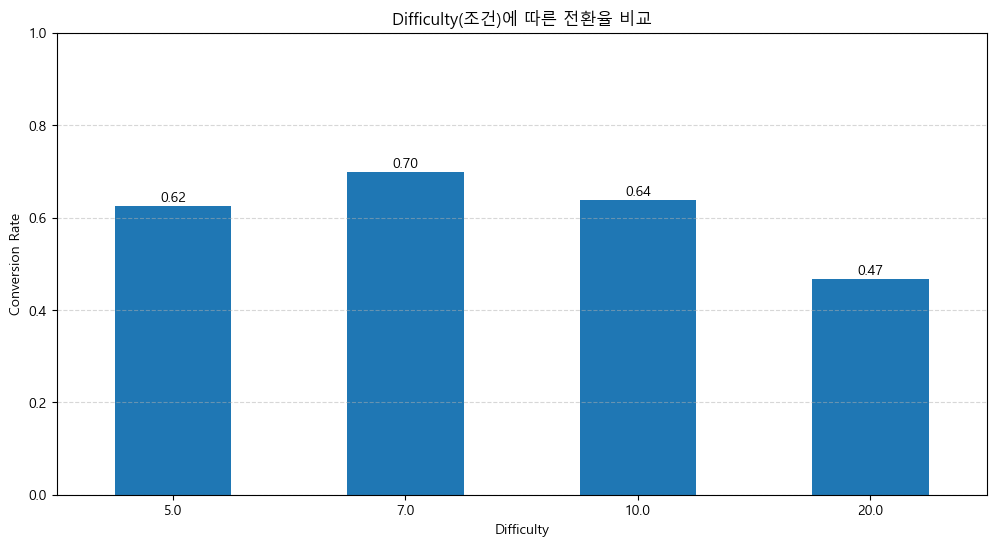

In [41]:
diff_plot = diff_df.dropna(subset=["conversion_rate"])

diff_plot["conversion_rate"].plot(kind="bar")

plt.title("Difficulty(조건)에 따른 전환율 비교")
plt.xlabel("Difficulty")
plt.ylabel("Conversion Rate")

plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 값 표시
for i, v in enumerate(diff_plot["conversion_rate"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

- 고객이 달성해야 하는 difficulty가 일정 수준을 넘으면 전환율이 급격히 떨어진다

In [19]:
# duration 영향
received = df_received.groupby("duration")["customer_id"].nunique()
completed = df_completed.groupby("duration")["customer_id"].nunique()

dur_df = pd.concat([received, completed], axis=1)
dur_df.columns = ["received", "completed"]

dur_df["conversion_rate"] = dur_df["completed"] / dur_df["received"]

In [20]:
channels = ["web", "email", "mobile", "social"]

for ch in channels:
    temp_received = df_received[df_received[ch] == 1]
    temp_completed = df_completed[df_completed[ch] == 1]
    
    r = temp_received["customer_id"].nunique()
    c = temp_completed["customer_id"].nunique()
    
    print(f"{ch} 전환율:", c / r)

web 전환율: 0.7388862615275479
email 전환율: 0.7516770624926444
mobile 전환율: 0.74075382803298
social 전환율: 0.6824974287615706


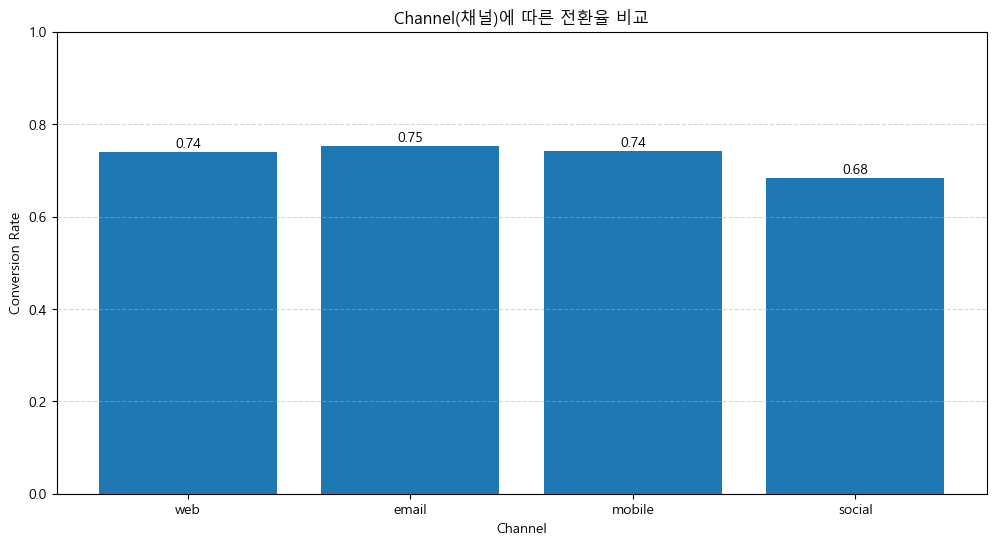

In [39]:
channels = ["web", "email", "mobile", "social"]
rates = [0.738886, 0.751677, 0.740754, 0.682497]

plt.bar(channels, rates)

plt.title("Channel(채널)에 따른 전환율 비교")
plt.xlabel("Channel")
plt.ylabel("Conversion Rate")

plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 값 표시
for i, v in enumerate(rates):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

직접적인 채널(email, mobile)이 전환에 더 효과적이며, social 채널은 상대적으로 구매 전환력이 낮다